# Monitoring Bench Press Sets with a Wrist-Worn IMU

Where in the push does a bench press lose acceleration, and does that change as the set goes on? We study this question on the Chest Press recordings of the RecoFit dataset.

*Contents:* 1 Background · 2 Data · 3 How the project developed · 4 Research questions and measurement · 5 to 10 Analysis · 11 Conclusions

## 1. Background

Coaches and athletes judge a set by more than the load on the bar. Technique matters, and so does how close the lifter came to muscular failure. Proximity to failure is the hardest of these to measure. There is no accepted standard, and the usual indicators rest on judgment: "that set was hard" says nothing about how hard, compared to what, or by whose measure.

Failure itself has several definitions, among them form-based, concentric, eccentric and velocity-based failure. Form-based failure is difficult to assess consistently, and a visible breakdown in technique tends to appear only after more fatigue has accumulated than intended. Since most training aims to get close to failure while technique still holds, a useful indicator has to respond before form breaks down.

Repetition velocity meets that requirement. It falls as fatigue builds up within a set, and the drop can be measured directly, which has made velocity loss one of the more objective effort measures in strength and conditioning. Its use in fully automated, everyday monitoring is still limited, so we start with one exercise and one use case: the bench press. Its goal in powerlifting is clearly defined (the heaviest single repetition with acceptable technique), and the movement is controlled enough to be studied repetition by repetition.

The second problem is record keeping. Logging load, repetitions and notes for every set takes a discipline many athletes do not keep up, and anything typed in or recalled afterwards adds uncertainty. A monitoring system should collect objective data without asking the athlete for input. Inertial measurement units (IMUs) record movement continuously, and a smartwatch is the most practical way to wear one. In this project the IMU, ideally a smartwatch, is the observer of the training session.

## 2. Data

Collecting new data was not possible in this first phase, so we looked for a public dataset that had been used in published research, had enough participants and included raw motion data. Size was the main constraint. Most public strength training datasets have 10 to 20 participants, enough for small experiments but limited for models that must generalize to new users.

RecoFit (Morris et al., CHI 2014) was the exception. It contains 126 sessions from 94 participants (28 female, aged 18 to 58), recorded with an armband on the right forearm holding a 3-axis accelerometer and a 3-axis gyroscope sampled at 50 Hz. Every set of its 26 exercises is labeled with the exercise, its start and end time and the number of repetitions. RecoFit was built to detect, recognize and count exercises, not to study fatigue. We chose it anyway, because the forearm placement is close to where a smartwatch sits and the participant pool is several times larger than in comparable datasets.

The dataset is distributed as MATLAB files. For the conversion we wrote a separate tool, [recofit-mat2csv-exercise-filter](https://github.com/erenalpckroglu/recofit-mat2csv-exercise-filter), which turns the `singleonly` file into two flat CSV files for a chosen set of exercises, one row per set and one row per sensor sample from the right-arm device. This repository works with its output for three exercises: 99 sets from 43 participants, 232,046 samples in total. Chest Press (rack), the RecoFit exercise closest to the bench press, is the focus of the analysis. Squat Rack Shoulder Press is included as a second pressing movement that is easy to confuse with it, and Lateral Raise as a clearly different arm movement.

## 3. How the project developed

The analysis was built in three notebooks, numbered in the order of work. Each runs on its own. This report summarizes them and compiles the final results.

**[01_legacy_signal_exploration.ipynb](https://github.com/erenalpckroglu/imu-repcognition/blob/main/notebooks/01_legacy_signal_exploration.ipynb)** is where we got to know the signals, before any model was trained. It examines which axis dominates each exercise and where a repetition starts and ends (sections 3 to 5), then compares three ways of choosing the signal before computing energy and tempo: the raw axes, the PCA projection used in RecoFit, and a gravity-based tilt correction we added ourselves (sections 6 to 9). The tilt correction was stable for Chest Press, where the estimated direction of gravity moved about 4° within a set, but failed for Lateral Raise and for one Shoulder Press set, so PCA stayed the default. Section 10 tests whether bar displacement can be recovered by integrating acceleration twice. For a 1.7 s repetition the naive estimate ends at 3 m/s and 2 m, and even with a zero-velocity correction the range of motion comes out at 0.69 m, about twice a realistic value. This is why the rest of the project works with velocity proxies.

**[02_ml_pipeline.ipynb](https://github.com/erenalpckroglu/imu-repcognition/blob/main/notebooks/02_ml_pipeline.ipynb)** trains and validates the models. Every evaluation uses five-fold cross-validation grouped by participant, so no person appears in both training and test data. For Chest Press against Lateral Raise, logistic regression, a linear SVM and a random forest all classify every set correctly, which says more about how easy the pair is than about the models. For repetition counting, a random forest regressor using period estimates from all six axes lowers the error from 1.93 to 1.57 repetitions for Chest Press and from 1.59 to 1.14 for Lateral Raise. Finally, a random forest classifier separates concentric from eccentric windows of 0.3 s with 0.80 accuracy against a 0.55 baseline. Its labels come from a peak and trough rule, so the result shows that the phase can be read from a short window; whether the rule itself is right remains open.

**[03_weak_region_analysis.ipynb](https://github.com/erenalpckroglu/imu-repcognition/blob/main/notebooks/03_weak_region_analysis.ipynb)** is the working version of sections 5 to 10 below. It detects the pushing phase of every Chest Press repetition, splits it into two halves and compares them within repetitions, within sets and between sets. This report runs the same code and adds context and interpretation.

An earlier prototype, including a first attempt at measuring slowdown within a repetition, is kept on the [repcognition-legacy](https://github.com/erenalpckroglu/imu-repcognition/tree/repcognition-legacy) branch.

## 4. Research questions and what the sensor can measure

Coaches often read where a lifter slows down in the press as a hint about what limits the lift. Trouble just off the chest is usually attributed to the pectorals and front deltoids, trouble near lockout to the triceps. We do not test that link. Our question is narrower: can a wrist sensor show in which half of the push the movement loses acceleration, and does that change over the course of a set?

Bar velocity itself is out of reach with this sensor, as section 10 of notebook 01 showed. Each push is described instead by two proxies, computed separately for its first and second half:

- **Dynamic acceleration RMS**, the energy of the acceleration magnitude after removing the static 1 g. Lower values mean less acceleration in that half.
- **Progress rate**, how fast the smoothed dominant-axis signal moves through its trough-to-peak range. It describes the timing of the push, not the speed of the bar.

Push boundaries are estimated from the shape of the signal, and RecoFit contains no ground truth for fatigue, failure or muscle activation. Every weak region reported below should be read as a candidate.

The analysis answers five questions:

1. Is the data balanced across the three exercises? (section 5)
2. Which set-level features separate the exercises, and do they recognize the exercise for a person the model has not seen? (section 6)
3. Within a Chest Press repetition, which half of the push shows lower acceleration? (sections 7 and 8)
4. Which half loses more acceleration from the start to the end of a set? (section 9)
5. Is the balance between the two halves stable across sets of the same participant? (section 10)

Helper functions for loading the data, detecting pushes and computing the half features are in [`analysis.py`](https://github.com/erenalpckroglu/imu-repcognition/blob/main/notebooks/analysis.py), next to this notebook.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from matplotlib.patches import Patch

from analysis import (
    ACC, GYR, CHEST, SHOULDER, LATERAL, EXERCISES, MIN_LABELLED_REPS,
    build_chest_half_features, build_recording_features,
    build_rep_comparison, build_set_comparison, detect_push_phases,
    load_data, load_signal, representative_record, short_sets,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False})
PALETTE = {CHEST: "#2878B5", SHOULDER: "#F39C35", LATERAL: "#4EAF49"}
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
recordings, samples = load_data()

## 5. The three exercises in the data

`recordings.csv` has one row per set with the participant and the labeled number of repetitions. `samples.csv` has one row per sample from the right-arm sensor, with acceleration in g and angular velocity in degrees per second. Three sets with fewer than five labeled repetitions (one, two and three) are excluded before any analysis, because tempo and within-set comparisons need a repeating movement. The same rule applies in notebooks 02 and 03, and it leaves 96 sets.

In [2]:
overview = recordings.groupby("activity_name").agg(
    sets=("record_uid", "count"),
    participants=("subject_id", "nunique"),
    labelled_reps=("activity_reps", "sum"),
    median_reps_per_set=("activity_reps", "median"),
).reindex(EXERCISES)

print(f"Recording-level table: {recordings.shape[0]} sets × {recordings.shape[1]} columns")
print(f"Sample-level table: {samples.shape[0]:,} timestamps × {samples.shape[1]} columns")
print(f"Missing sensor values: {samples[ACC + GYR].isna().sum().sum():,}")
print(f"Sets flagged incomplete by RecoFit: {(recordings.incomplete_data == 1).sum()}")
display(overview)
print(f"Excluded before analysis, fewer than {MIN_LABELLED_REPS} labelled repetitions:")
display(short_sets())

Recording-level table: 96 sets × 8 columns
Sample-level table: 230,576 timestamps × 10 columns
Missing sensor values: 0
Sets flagged incomplete by RecoFit: 2


,sets,participants,labelled_reps,median_reps_per_set
activity_name,,,,
Chest Press (rack),30,21,492,16.0
Squat Rack Shoulder Press,32,29,503,15.0
Lateral Raise,34,30,503,15.0


Excluded before analysis, fewer than 5 labelled repetitions:


,record_uid,activity_name,activity_reps
0,singleonly_subject093_Chest_Press_(rack)_recor...,Chest Press (rack),3
1,singleonly_subject054_Squat_Rack_Shoulder_Pres...,Squat Rack Shoulder Press,2
2,singleonly_subject055_Lateral_Raise_record0001,Lateral Raise,1


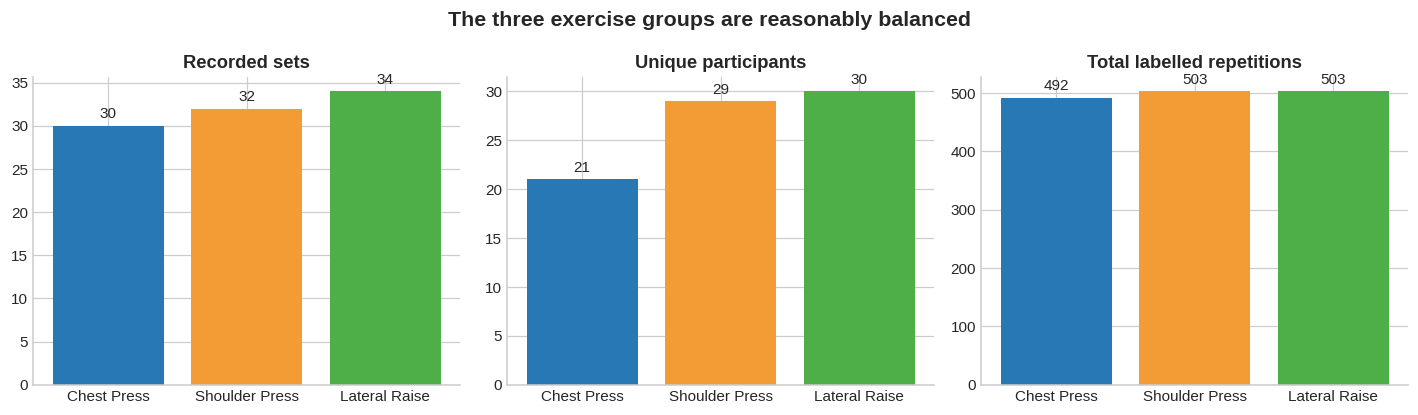

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, column, title in zip(axes, ["sets", "participants", "labelled_reps"], ["Recorded sets", "Unique participants", "Total labelled repetitions"]):
    values = overview[column]
    bars = ax.bar(range(3), values, color=[PALETTE[x] for x in EXERCISES])
    ax.set_xticks(range(3), ["Chest Press", "Shoulder Press", "Lateral Raise"])
    ax.set_title(title)
    ax.bar_label(bars, padding=3)
fig.suptitle("The three exercise groups are reasonably balanced", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Each exercise has about 500 labeled repetitions. Chest Press comes from fewer people, 21 participants against 29 and 30, because several of them recorded more than one set.

### A first look at the signals

Acceleration and gyroscope magnitudes lose the direction of the movement but do not depend on how the sensor sits on the arm, which keeps recordings from different participants comparable. Each row shows the first 12 seconds of the set whose gyroscope energy is closest to the median of its exercise. The axes are shared, so amplitudes can be compared directly.

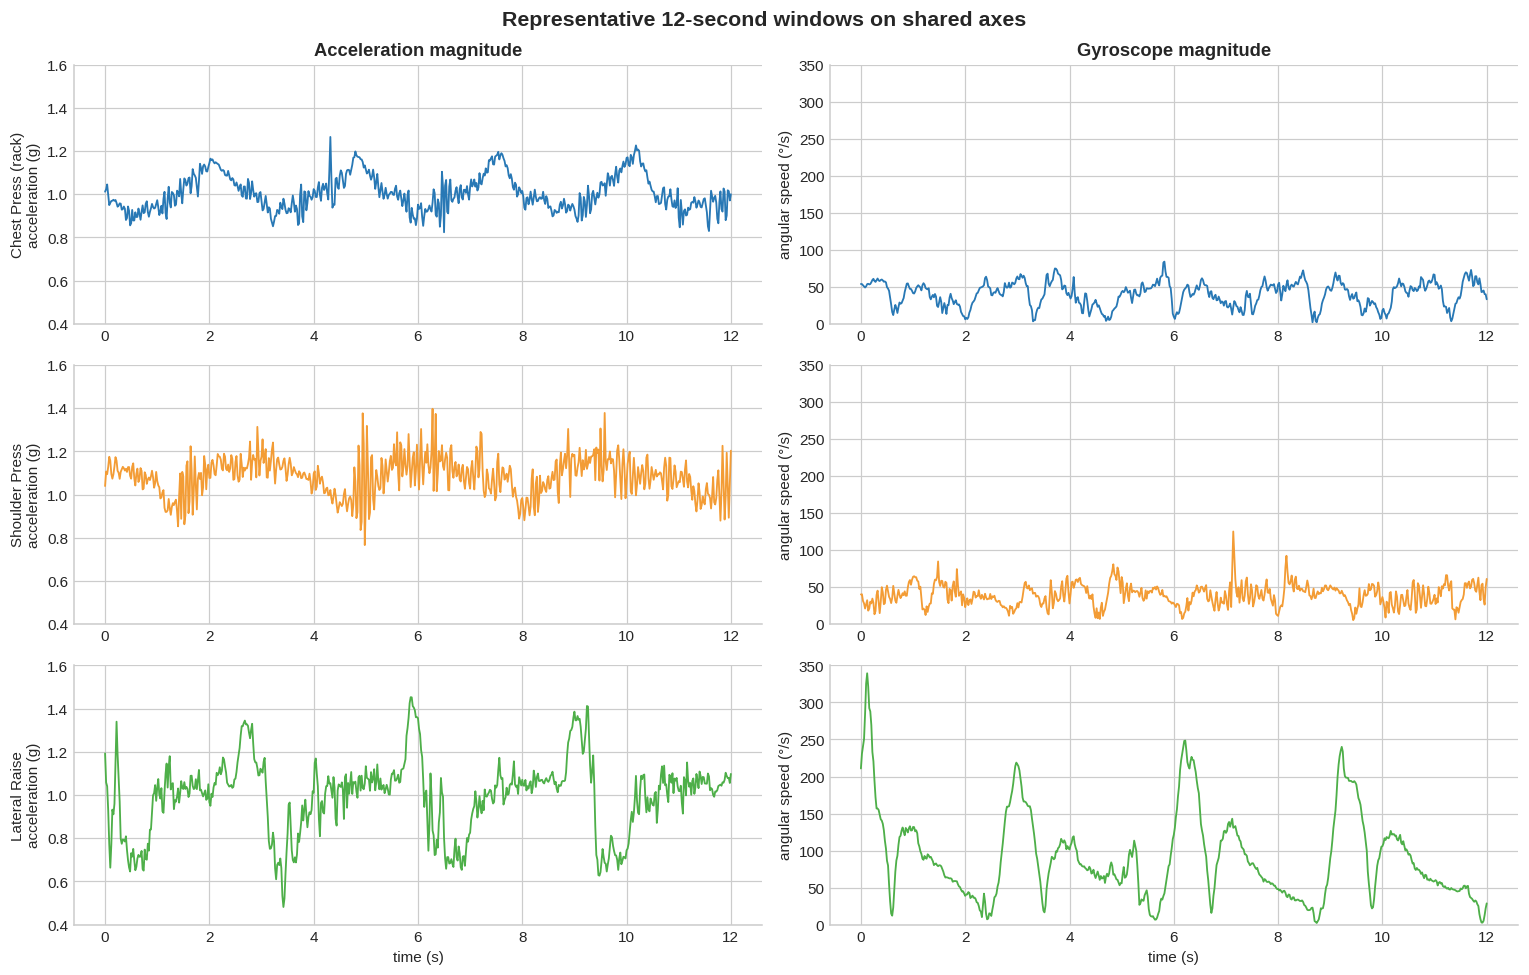

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharey="col")
for row, exercise in enumerate(EXERCISES):
    uid = representative_record(recordings, samples, exercise)
    signal = load_signal(samples, uid)
    time_s = (signal.time_s - signal.time_s.iloc[0]).to_numpy()
    mask = time_s <= 12
    accel_mag = np.linalg.norm(signal[ACC].to_numpy(), axis=1)
    gyro_mag = np.linalg.norm(signal[GYR].to_numpy(), axis=1)
    axes[row, 0].plot(time_s[mask], accel_mag[mask], color=PALETTE[exercise], lw=1.2)
    axes[row, 1].plot(time_s[mask], gyro_mag[mask], color=PALETTE[exercise], lw=1.2)
    axes[row, 0].set_ylabel(exercise.replace("Squat Rack ", "") + "\nacceleration (g)")
    axes[row, 1].set_ylabel("angular speed (°/s)")
axes[0, 0].set_ylim(0.4, 1.6)
axes[0, 1].set_ylim(0, 350)
axes[0, 0].set_title("Acceleration magnitude")
axes[0, 1].set_title("Gyroscope magnitude")
axes[-1, 0].set_xlabel("time (s)")
axes[-1, 1].set_xlabel("time (s)")
fig.suptitle("Representative 12-second windows on shared axes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Comparing and recognizing the exercises

Each set is reduced to one row of features: duration, seconds per labeled repetition, variability and dynamic RMS of the acceleration magnitude, gyroscope RMS, range of the dominant axis, and tempo from autocorrelation.

In [5]:
recording_features = build_recording_features(recordings, samples)
recording_features.to_csv(OUTPUT_DIR / "recording_features.csv", index=False)
feature_summary = recording_features.groupby("exercise")[[
    "duration_s", "seconds_per_labelled_rep", "accel_dynamic_rms_g",
    "gyro_mag_rms_dps", "tempo_period_s"
]].median().reindex(EXERCISES).round(2)
display(feature_summary)
print(f"Median estimated sampling rate: {recording_features.sample_rate_hz.median():.2f} Hz")

,duration_s,seconds_per_labelled_rep,accel_dynamic_rms_g,gyro_mag_rms_dps,tempo_period_s
exercise,,,,,
Chest Press (rack),42.79,2.53,0.12,42.81,2.19
Squat Rack Shoulder Press,53.81,3.64,0.11,40.36,2.95
Lateral Raise,38.12,2.64,0.17,110.32,2.59


Median estimated sampling rate: 50.00 Hz


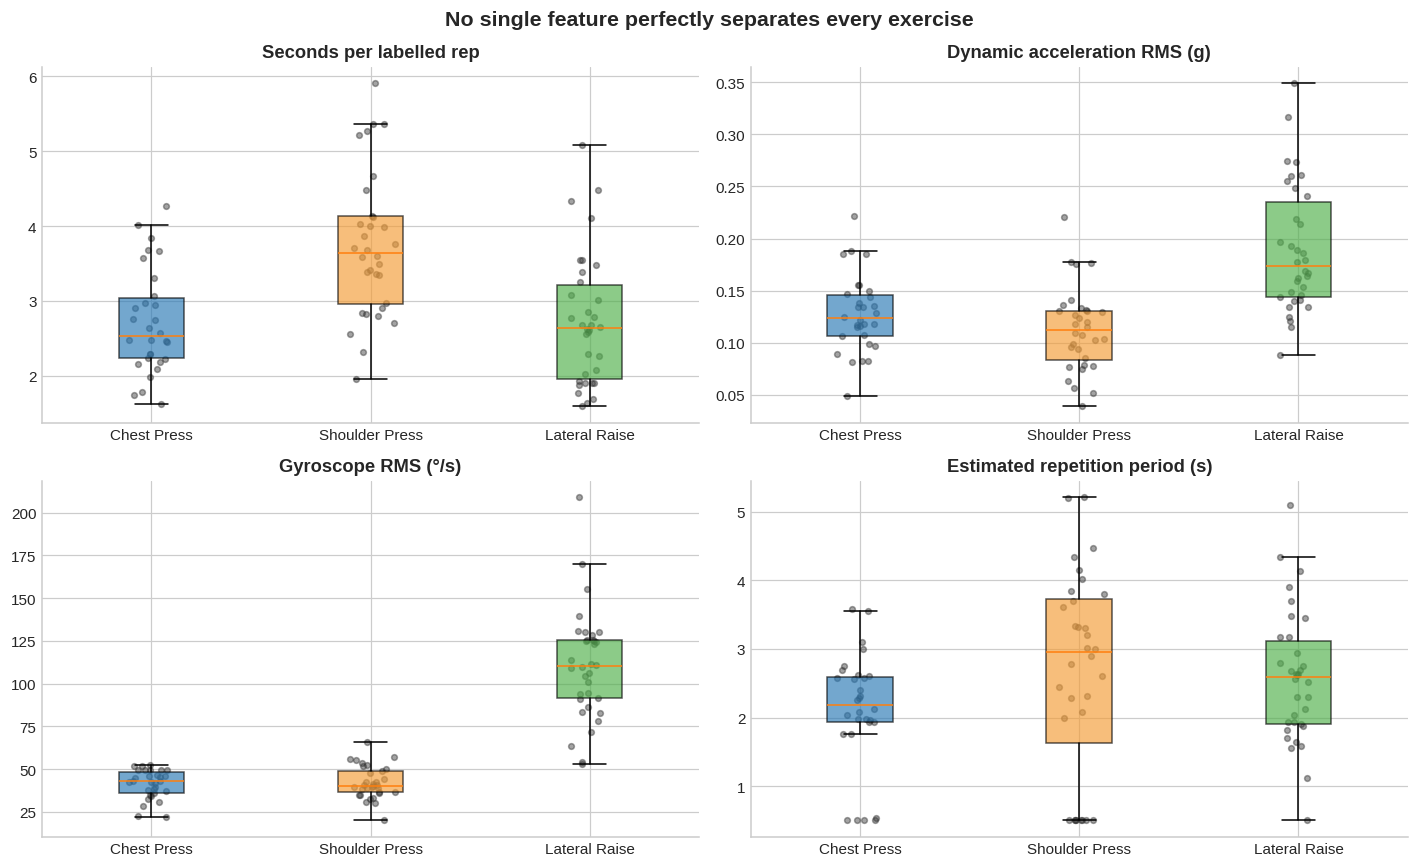

In [6]:
plot_features = ["seconds_per_labelled_rep", "accel_dynamic_rms_g", "gyro_mag_rms_dps", "tempo_period_s"]
plot_titles = ["Seconds per labelled rep", "Dynamic acceleration RMS (g)", "Gyroscope RMS (°/s)", "Estimated repetition period (s)"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, feature, title in zip(axes.flat, plot_features, plot_titles):
    groups = [recording_features.loc[recording_features.exercise == ex, feature].dropna() for ex in EXERCISES]
    box = ax.boxplot(groups, patch_artist=True, tick_labels=["Chest Press", "Shoulder Press", "Lateral Raise"], showfliers=False)
    for patch, exercise in zip(box["boxes"], EXERCISES):
        patch.set_facecolor(PALETTE[exercise]); patch.set_alpha(0.65)
    for index, values in enumerate(groups, start=1):
        jitter = np.random.default_rng(7 + index).normal(index, 0.045, len(values))
        ax.scatter(jitter, values, s=14, color="#333333", alpha=0.45)
    ax.set_title(title)
fig.suptitle("No single feature perfectly separates every exercise", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Lateral Raise stands out through its gyroscope energy, about 110 °/s against roughly 40 °/s for the two presses. Shoulder Press repetitions take the longest. No single feature separates all three exercises.

### Recognition check

A logistic regression on these features is evaluated with five-fold cross-validation grouped by participant. Each set is therefore predicted by a model that has never seen any set of that person, which is the situation of a new user.

Fold accuracies: [0.8   0.789 0.842 0.737 0.842]
Mean subject-grouped accuracy: 0.802


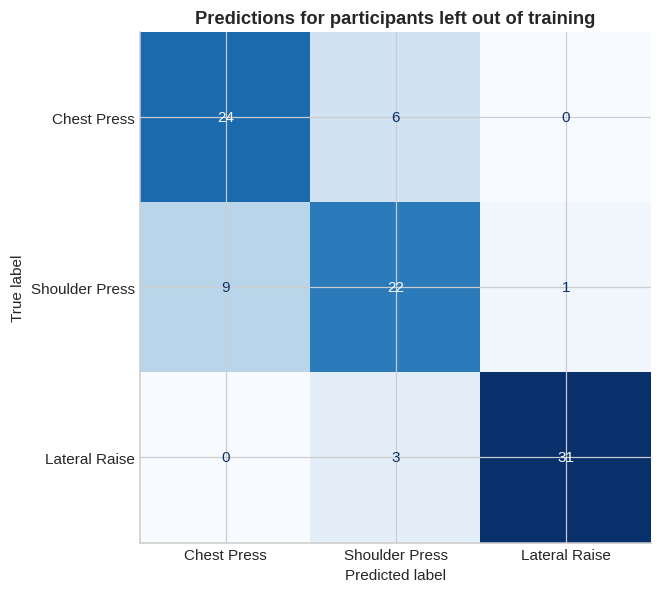

In [7]:
model_features = ["duration_s", "seconds_per_labelled_rep", "accel_mag_std_g", "accel_dynamic_rms_g", "gyro_mag_rms_dps", "dominant_accel_range_g", "tempo_period_s"]
X = recording_features[model_features]
y = recording_features.exercise
groups = recording_features.subject_id
model = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(max_iter=3000))
cv = GroupKFold(n_splits=5)
scores = cross_val_score(model, X, y, groups=groups, cv=cv)
predictions = cross_val_predict(model, X, y, groups=groups, cv=cv)
print("Fold accuracies:", np.round(scores, 3))
print(f"Mean subject-grouped accuracy: {scores.mean():.3f}")
fig, ax = plt.subplots(figsize=(6.8, 5.5))
ConfusionMatrixDisplay.from_predictions(y, predictions, labels=EXERCISES, display_labels=["Chest Press", "Shoulder Press", "Lateral Raise"], cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Predictions for participants left out of training")
plt.tight_layout()
plt.show()

Mean accuracy is 0.80, with folds between 0.74 and 0.84. Lateral Raise is recognized best (31 of 34 sets). Most errors are between the two presses: 6 Chest Press sets are taken for Shoulder Press and 9 the other way round. For three classes this is a baseline. Without Shoulder Press the task becomes easy, and the pipeline in notebook 02 classifies every set correctly.

## 7. Splitting each push into two halves

Push detection runs on the dominant acceleration axis. The signal is smoothed, autocorrelation gives the typical spacing between repetitions, and every trough-to-peak section is taken as a push. A push that contains another trough is discarded, since a peak was missed and the section runs into the next repetition. Each push is resampled to 101 points and split into two halves of equal duration, and both proxies from section 4 are computed for each half. The tables at half, repetition and set level are saved to `outputs/`.

In [8]:
half_features, profiles = build_chest_half_features(recordings, samples)
rep_comparison = build_rep_comparison(half_features)
set_comparison = build_set_comparison(rep_comparison)
half_features.to_csv(OUTPUT_DIR / "chest_press_half_features.csv", index=False)
rep_comparison.to_csv(OUTPUT_DIR / "chest_press_rep_comparison.csv", index=False)
set_comparison.to_csv(OUTPUT_DIR / "chest_press_set_comparison.csv", index=False)

chest_truth = recordings.loc[recordings.activity_name == CHEST, ["record_uid", "activity_reps"]]
coverage = chest_truth.merge(set_comparison[["record_uid", "detected_reps"]], on="record_uid", how="left").fillna({"detected_reps": 0})
coverage["absolute_count_error"] = (coverage.activity_reps - coverage.detected_reps).abs()
print(f"Detected pushes: {len(rep_comparison)} across {set_comparison.record_uid.nunique()} of {len(chest_truth)} sets")
print(f"Detection-count MAE: {coverage.absolute_count_error.mean():.2f} repetitions")
display(coverage.loc[coverage.detected_reps == 0])

Detected pushes: 414 across 29 of 30 sets
Detection-count MAE: 3.00 repetitions


,record_uid,activity_reps,detected_reps,absolute_count_error
2,singleonly_subject007_Chest_Press_(rack)_recor...,20,0.0,20.0


The method finds 414 pushes in 29 of the 30 sets. The detected count differs from the labeled repetitions by 3.0 on average; discarding pushes that run into the next repetition costs some count accuracy in exchange for cleaner pushes. The set without any detected push (`subject007`) has unusually low signal variance and is the same recording that defeated the signal-processing counter in notebook 02.

The plot shows the first 20 seconds of the set with the most detected pushes. Arrows give the duration of each push, and the percentages at the bottom the share of the movement completed in each half. Both halves last the same time, so a smaller share means the movement was slower in that half.

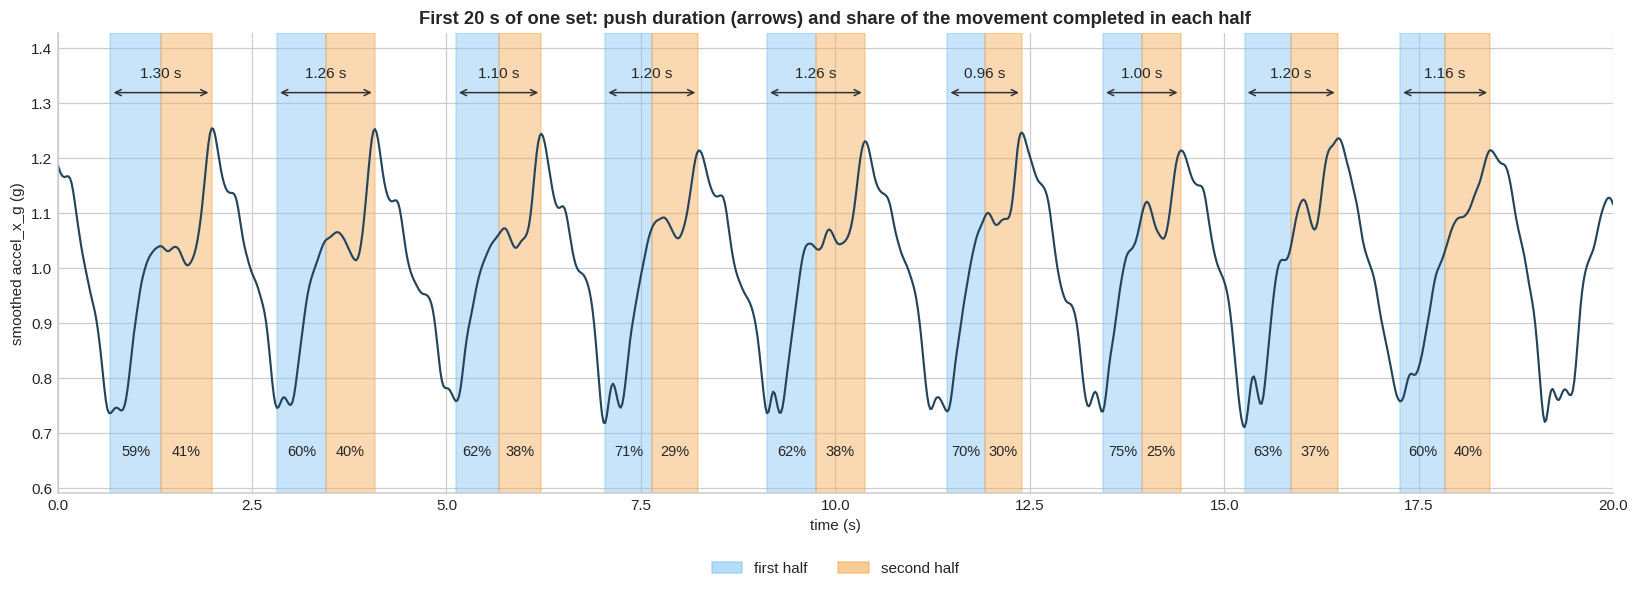

In [9]:
example_uid = set_comparison.sort_values("detected_reps", ascending=False).iloc[0].record_uid
signal = load_signal(samples, example_uid)
axis, raw, filtered, phases = detect_push_phases(signal)
time_s = (signal.time_s - signal.time_s.iloc[0]).to_numpy()
window_s = 20
mask = time_s <= window_s
shares = half_features.loc[half_features.record_uid == example_uid].set_index(["rep_index", "half"]).rise_fraction
top, bottom = filtered[mask].max(), filtered[mask].min()
span = top - bottom
fig, ax = plt.subplots(figsize=(15, 5.5))
ax.plot(time_s[mask], filtered[mask], color="#24445C", lw=1.4)
for rep_number, (start, end) in enumerate(phases, start=1):
    if time_s[end] > window_s:
        break
    t0, t1 = time_s[start], time_s[end]
    mid = (t0 + t1) / 2
    ax.axvspan(t0, mid, color="#84C5F4", alpha=0.45)
    ax.axvspan(mid, t1, color="#F6AA54", alpha=0.45)
    y_arrow = top + 0.12 * span
    ax.annotate("", xy=(t0, y_arrow), xytext=(t1, y_arrow), arrowprops=dict(arrowstyle="<->", color="#333333", lw=1))
    ax.text(mid, y_arrow + 0.04 * span, f"{t1 - t0:.2f} s", ha="center", va="bottom", fontsize=10)
    for half, x in (("first", (t0 + mid) / 2), ("second", (mid + t1) / 2)):
        if (rep_number, half) in shares.index:
            ax.text(x, bottom - 0.06 * span, f"{shares[(rep_number, half)]:.0%}", ha="center", va="top", fontsize=9.5)
ax.set_xlim(0, window_s)
ax.set_ylim(bottom - 0.22 * span, top + 0.32 * span)
ax.legend(handles=[Patch(color="#84C5F4", alpha=0.6, label="first half"), Patch(color="#F6AA54", alpha=0.6, label="second half")], loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
ax.set(xlabel="time (s)", ylabel=f"smoothed {axis} (g)",
       title=f"First {window_s} s of one set: push duration (arrows) and share of the movement completed in each half")
plt.tight_layout()
plt.show()

## 8. Within-repetition comparison

Each point is one push. Below the diagonal the second half has less acceleration energy, above it the first half.

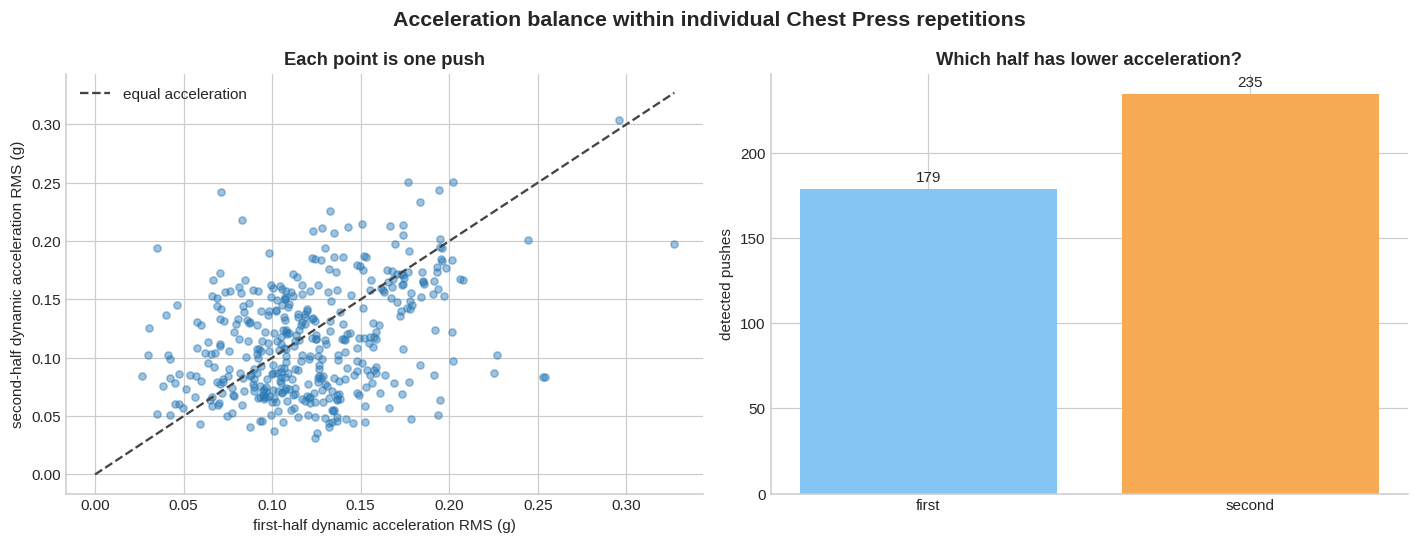

,second_to_first_accel_energy,second_to_first_progress_rate
count,414.000,414.000
mean,1.045,1.209
std,0.576,1.045
min,0.254,0.006
25%,0.685,0.550
50%,0.940,0.969
75%,1.273,1.587
max,5.564,9.222


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(rep_comparison.dynamic_accel_rms_g_first, rep_comparison.dynamic_accel_rms_g_second, s=22, alpha=0.45, color=PALETTE[CHEST])
limit = max(rep_comparison.dynamic_accel_rms_g_first.max(), rep_comparison.dynamic_accel_rms_g_second.max())
axes[0].plot([0, limit], [0, limit], "--", color="#444444", label="equal acceleration")
axes[0].set(xlabel="first-half dynamic acceleration RMS (g)", ylabel="second-half dynamic acceleration RMS (g)", title="Each point is one push")
axes[0].legend()
counts = rep_comparison.lower_acceleration_half.value_counts().reindex(["first", "second"]).fillna(0)
bars = axes[1].bar(counts.index, counts.values, color=["#84C5F4", "#F6AA54"])
axes[1].bar_label(bars, padding=3)
axes[1].set(title="Which half has lower acceleration?", ylabel="detected pushes")
fig.suptitle("Acceleration balance within individual Chest Press repetitions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
display(rep_comparison[["second_to_first_accel_energy", "second_to_first_progress_rate"]].describe().round(3))

The second half is the lower one in 235 of 414 pushes (57%). The median ratio of second-half to first-half energy is 0.94, but the middle half of all pushes spans 0.69 to 1.27, so the lower half often changes from one repetition to the next. Progress rate gives the same picture: its median ratio is 0.97, and 48% of pushes move faster through the second half. At the level of single repetitions, neither half clearly dominates.

## 9. Within-set fatigue

For each set, the first 30% of detected repetitions are compared with the last 30%, separately for each half. A late-to-early energy ratio below 1 means that half lost acceleration during the set. A half is flagged as the candidate fatigue-sensitive half only if its energy dropped by at least 10%. Sets without such a drop are marked `none`. The threshold is our own choice and has not been validated, and sets with fewer than six detected repetitions are never flagged.

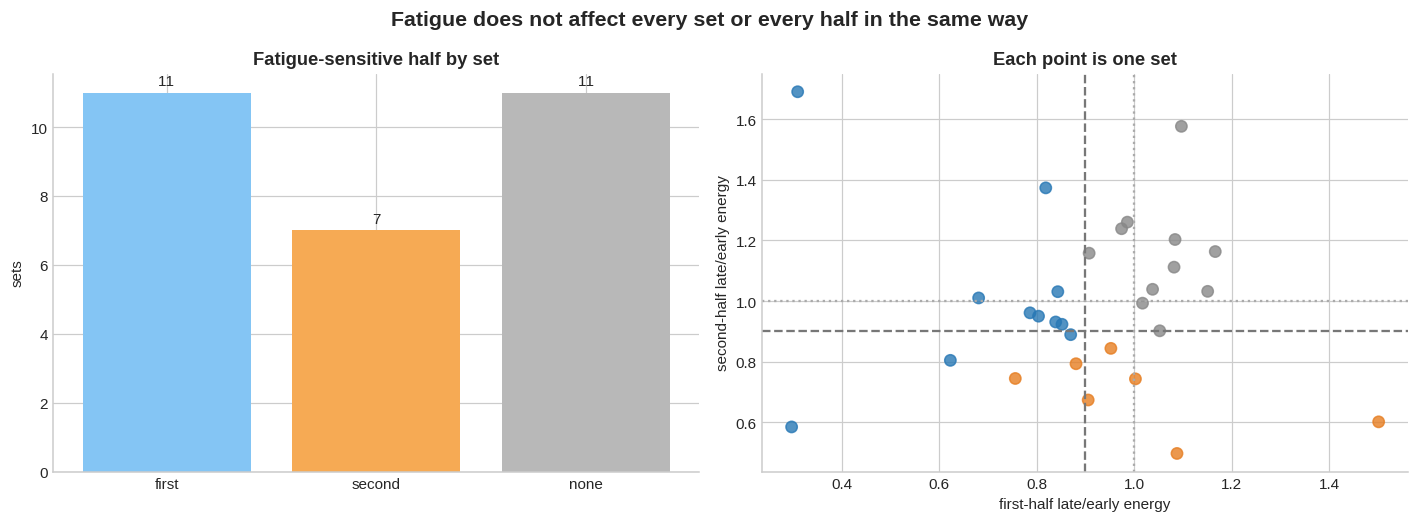

,sets
candidate_fatigue_sensitive_half,
first,11
second,7
none,11


In [11]:
candidate_counts = set_comparison.candidate_fatigue_sensitive_half.value_counts().reindex(["first", "second", "none"]).fillna(0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
bars = axes[0].bar(candidate_counts.index, candidate_counts.values, color=["#84C5F4", "#F6AA54", "#B8B8B8"])
axes[0].bar_label(bars, padding=3)
axes[0].set(title="Fatigue-sensitive half by set", ylabel="sets")
axes[1].scatter(set_comparison.first_half_late_to_early_energy, set_comparison.second_half_late_to_early_energy, c=[{"first": "#2878B5", "second": "#E67E22", "none": "#888888"}[x] for x in set_comparison.candidate_fatigue_sensitive_half], s=55, alpha=0.8)
axes[1].axvline(0.9, ls="--", color="#777777"); axes[1].axhline(0.9, ls="--", color="#777777")
axes[1].axvline(1.0, ls=":", color="#AAAAAA"); axes[1].axhline(1.0, ls=":", color="#AAAAAA")
axes[1].set(xlabel="first-half late/early energy", ylabel="second-half late/early energy", title="Each point is one set")
fig.suptitle("Fatigue does not affect every set or every half in the same way", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
display(candidate_counts.rename("sets").to_frame())

Eleven sets are flagged in the first half, seven in the second and eleven in neither. Where fatigue shows up differs between lifters, which argues for a baseline per lifter instead of one threshold for everyone. The set with the strongest drop is shown below: in its last repetitions, first-half energy falls to 30% of the early level and second-half energy to 59%.

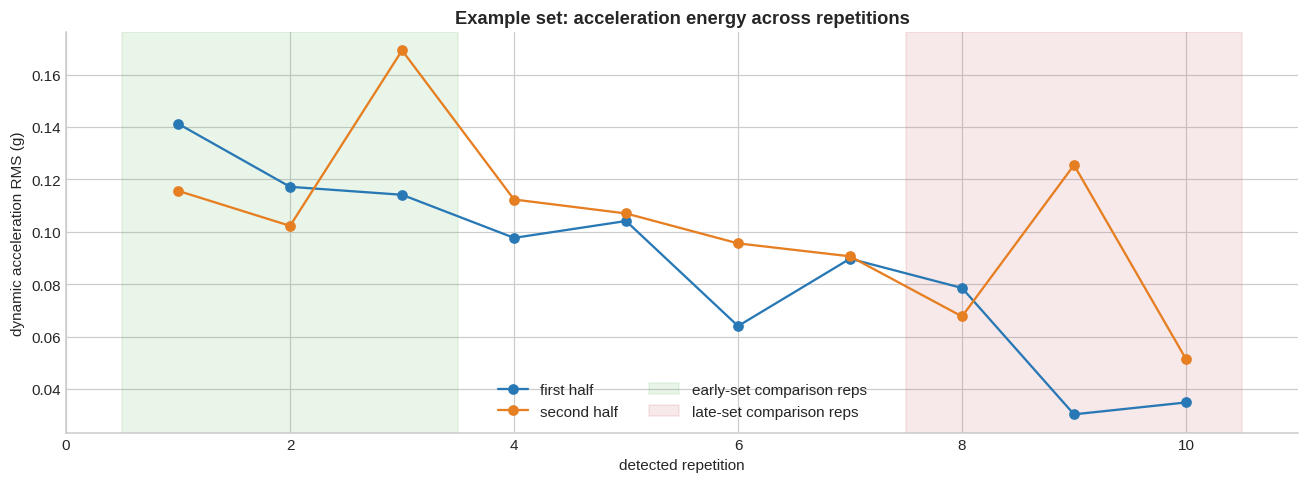

In [12]:
flagged = set_comparison.loc[set_comparison.candidate_fatigue_sensitive_half != "none"].copy()
flagged["strongest_drop"] = flagged[["first_half_late_to_early_energy", "second_half_late_to_early_energy"]].min(axis=1)
fatigue_uid = flagged.sort_values("strongest_drop").iloc[0].record_uid
example_reps = rep_comparison.loc[rep_comparison.record_uid == fatigue_uid].sort_values("rep_index")
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(example_reps.rep_index, example_reps.dynamic_accel_rms_g_first, marker="o", label="first half", color="#2878B5")
ax.plot(example_reps.rep_index, example_reps.dynamic_accel_rms_g_second, marker="o", label="second half", color="#E67E22")
edge = max(2, int(np.ceil(0.30 * len(example_reps))))
ax.axvspan(0.5, edge + 0.5, color="#4EAF49", alpha=0.12, label="early-set comparison reps")
ax.axvspan(len(example_reps) - edge + 0.5, len(example_reps) + 0.5, color="#C44E52", alpha=0.12, label="late-set comparison reps")
ax.set(xlabel="detected repetition", ylabel="dynamic acceleration RMS (g)", title="Example set: acceleration energy across repetitions")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

## 10. Comparison between sets

Set medians dampen the effect of single noisy repetitions. The left panel compares the typical energy of the two halves in every set, the right panel follows the six participants who recorded more than one Chest Press set.

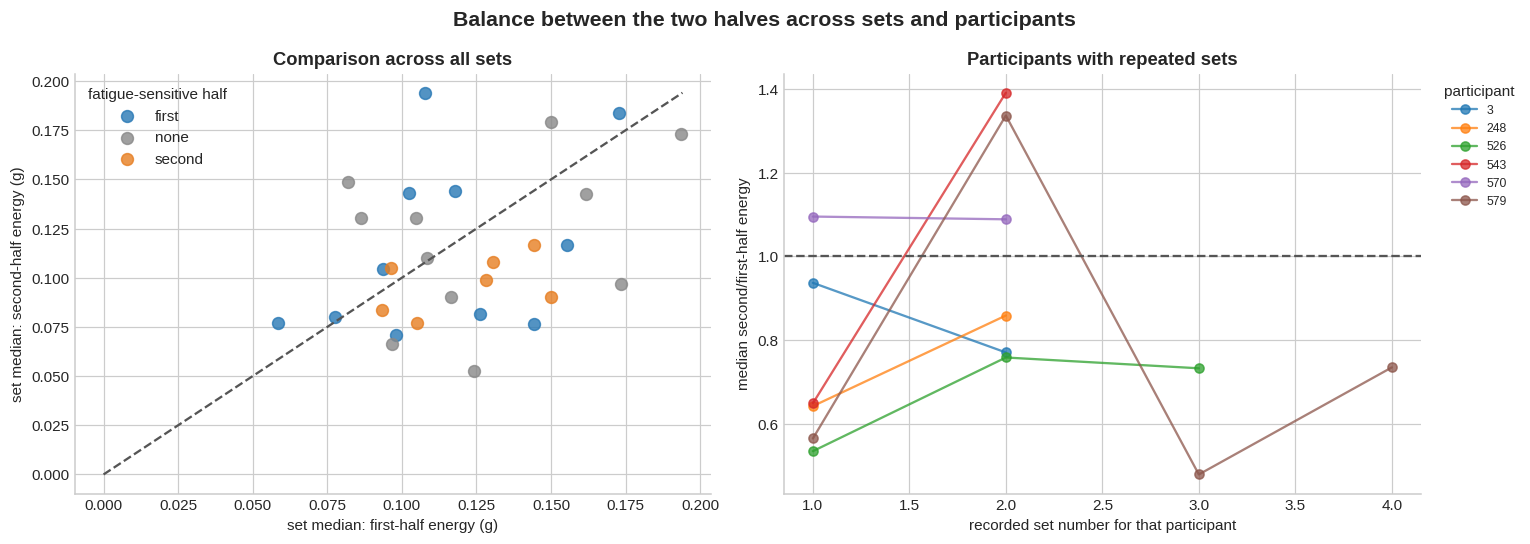

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
color_map = {"first": "#2878B5", "second": "#E67E22", "none": "#888888"}
for label, group in set_comparison.groupby("candidate_fatigue_sensitive_half"):
    axes[0].scatter(group.median_first_half_accel_rms_g, group.median_second_half_accel_rms_g, s=60, alpha=0.8, color=color_map[label], label=label)
limit = max(set_comparison.median_first_half_accel_rms_g.max(), set_comparison.median_second_half_accel_rms_g.max())
axes[0].plot([0, limit], [0, limit], "--", color="#555555")
axes[0].set(xlabel="set median: first-half energy (g)", ylabel="set median: second-half energy (g)", title="Comparison across all sets")
axes[0].legend(title="fatigue-sensitive half")

repeated_subjects = set_comparison.groupby("subject_id").filter(lambda frame: len(frame) > 1)
for subject_id, group in repeated_subjects.groupby("subject_id"):
    group = group.reset_index(drop=True)
    axes[1].plot(np.arange(1, len(group) + 1), group.median_second_to_first_accel_energy, marker="o", alpha=0.75, label=str(subject_id))
axes[1].axhline(1.0, ls="--", color="#555555")
axes[1].set(xlabel="recorded set number for that participant", ylabel="median second/first-half energy", title="Participants with repeated sets")
axes[1].legend(title="participant", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle("Balance between the two halves across sets and participants", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In 16 of the 29 sets the second half has less energy. Of the six participants with repeated sets, four keep the same lower half in every set and two switch between sets. With so few repeated sets, that is at most a hint of individual consistency.

## 11. Conclusions

A single wrist IMU recognizes the three exercises with 0.80 accuracy for participants left out of training, and it segments Chest Press repetitions automatically in 29 of 30 sets. Within a repetition, the second half of the push has the lower acceleration energy slightly more often than the first (57% of pushes), but which half is lower varies from one repetition to the next. Over a set, the loss of acceleration concentrates in the first half in eleven sets and in the second half in seven. In the coaching reading from section 4, the first group would point to the start of the press and the second to lockout. The sensor can show where acceleration fades within a given set. It does not reveal one weak region shared by all lifters.

These results rest on proxies. Acceleration energy and progress rate are not bar velocity, push boundaries come from the signal shape, and the 10% threshold is exploratory. RecoFit has no ground truth for fatigue, failure or muscle activation. Its participants picked their own weights and repetition counts from a suggested range, and nothing in the protocol asked them to approach failure, so many sets probably ended well short of it. Most participants also recorded only one Chest Press set, and the sample is small enough for single sets to matter: excluding the three shortest sets raised three-exercise recognition from 0.74 to 0.80.

The next phase needs data collected for this question: a smartwatch recorded together with a linear position transducer or side-view video for bar velocity, sets taken close to failure at known loads, and several sets per lifter. That would allow the acceleration proxies to be checked against measured velocity loss, and the bottom and lockout regions to be labeled independently.